# 06 - Event identification: chunk a video, embed the clips, find the fight
Notebooks 02-05 asked *which video in this corpus matches the query*. Event identification flips the direction: you hold long footage and a bank of event descriptions, and you want to know **where** - in which seconds - something happens. The standard recipe:

> chunk the footage into short clips -> embed each clip once (index time) -> score text queries against all clips (query time) -> alert where a query lights up

Today we run that pipeline on **`fight_2.mp4`** (1920x1080, 25 fps, 7.5 s - real fight footage supplied for this lab, `~/study/data/fight_2.mp4`), with the lab's benign corpus chunked the same way as negative control:
1. Chunk everything into **5-second clips** with ffmpeg -> a 9-clip 'surveillance index' (2 fight + 7 benign).
2. Embed the index and *inspect* what the model actually consumes per clip.
3. Identify the fight by **text query** - score matrix and **margin** (fight clip - best benign clip).
4. Embed the queries under **different instructions** and watch what happens to the margin.
5. Same for instructions on the **clip (index) side**.
6. The payoff: **margin = the room you have to place a detection threshold** - we compute the valid threshold window per instruction.

(Background from earlier notebooks: instructions are system prompts - nb 04; one visual token = 1024 px and the pixel budget - nb 03.)

In [1]:
import os, sys
LAB_ROOT = "/home/satishv/study/qwen3-embed-lab"
sys.path.insert(0, LAB_ROOT)
from lab_helpers import *   # wrappers, VIDEOS, VIDEO_QUERIES, embed(), inspect_entry(), plotting, ...
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
print_gpu()
import subprocess
from pathlib import Path

/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GB10 (cuda)


/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


## Part 1 - Chunk the footage into 5-second clips
Chunking is a plain ffmpeg job with one decision: `-c copy` (stream copy) is instant but cuts land on keyframes - up to seconds off. We **re-encode** (`libx264 -crf 23`) so every window starts exactly on time. Two details that matter for embedding:
- the **tail chunk** is whatever is left (7.52 s -> 5.00 s + 2.52 s) - short chunks embed fine, the wrapper enforces a 4-frame floor,
- positives and negatives must be **chunked and embedded identically**, so the benign corpus videos go through the exact same function.
Derived clips land in `data/clips/` (regenerable; the lab never edits its sources).

In [2]:
SRC = "/home/satishv/study/data/fight_2.mp4"          # the event footage under test
CLIP_DIR = Path(LAB_ROOT) / "data" / "clips"          # derived data - regenerable

def chunk_video(src, chunk_s=5.0, out_dir=CLIP_DIR):
    """Cut src into chunk_s-second clips (re-encoded for frame-accurate cuts)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    dur = float(subprocess.check_output([
        "ffprobe", "-v", "error", "-select_streams", "v:0",
        "-show_entries", "stream=duration", "-of", "csv=p=0", str(src)]).decode().strip())
    clips, start, i = [], 0.0, 0
    while start < dur - 0.1:                          # -0.1: never emit a zero-length tail
        end = min(start + chunk_s, dur); i += 1
        path = out_dir / f"{Path(src).stem}_c{i:02d}.mp4"
        if not path.exists():                        # cache: chunks are deterministic
            subprocess.run(["ffmpeg", "-v", "error", "-y", "-ss", f"{start:.3f}",
                            "-t", f"{end - start:.3f}", "-i", str(src),
                            "-c:v", "libx264", "-crf", "23", "-an", str(path)], check=True)
        clips.append(dict(name=path.stem, path=str(path),
                          t0=round(start, 2), dur=round(end - start, 2)))
        start = end
    return clips

fight_clips = chunk_video(SRC)
benign_clips = []
for k in ["bbb_1080", "jellyfish_720", "flower", "sintel_10s"]:
    benign_clips += chunk_video(str(VIDEOS[k]))

INDEX = fight_clips + benign_clips
CLIP_LABELS = [c["name"] for c in INDEX]
FIGHT_IDX = list(range(len(fight_clips)))            # ground truth: clips 0..1 are the fight

print(f"{Path(SRC).name}: {len(fight_clips)} fight chunks + {len(benign_clips)} benign chunks")
for c in INDEX:
    tag = "FIGHT" if c in fight_clips else "benign"
    print(f"  [{tag:5s}] {c['name']:18s} t0={c['t0']:5.2f}s  dur={c['dur']:4.2f}s")

fight_2.mp4: 2 fight chunks + 7 benign chunks
  [FIGHT] fight_2_c01        t0= 0.00s  dur=5.00s
  [FIGHT] fight_2_c02        t0= 5.00s  dur=2.52s
  [benign] bbb_1080_c01       t0= 0.00s  dur=5.00s
  [benign] bbb_1080_c02       t0= 5.00s  dur=5.00s
  [benign] jellyfish_720_c01  t0= 0.00s  dur=5.00s
  [benign] jellyfish_720_c02  t0= 5.00s  dur=5.00s
  [benign] flower_c01         t0= 0.00s  dur=5.00s
  [benign] sintel_10s_c01     t0= 0.00s  dur=5.00s
  [benign] sintel_10s_c02     t0= 5.00s  dur=5.00s


## Part 2 - Embed the clip index & inspect what the model consumes
The 9 clips are embedded once, default instruction on the clip side (we vary that in Part 5). Then the ritual from notebook 03 - **verify, don't trust**: what does the model actually consume for one 5 s 1080p chunk?

`torch_dtype` is deprecated! Use `dtype` instead!
qwen-vl-utils using torchvision to read video.
/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


clip index embeddings: (9, 2048)
fight_2_c01 (5.00s): 4 frames @ 1152x640 (737,280 px/frame = 720 tok/frame -> 2,880 visual tokens)


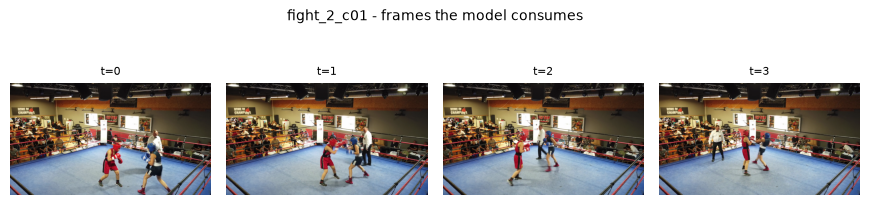

fight_2_c02 (2.52s): 4 frames @ 1152x640 (737,280 px/frame = 720 tok/frame -> 2,880 visual tokens)


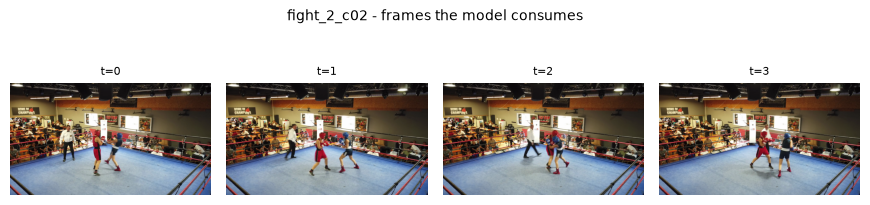

In [3]:
embedder = load_embedder("2B")

doc_emb = embed(embedder, [{"video": c["path"]} for c in INDEX])   # clip side: default instruction
print("clip index embeddings:", tuple(doc_emb.shape))

for c in fight_clips:
    info = inspect_entry(embedder, {"video": c["path"]})
    print(f"{c['name']} ({c['dur']:.2f}s): {summarize_inspection(info)}")
    show_frames(info["videos"][0]["tensor"], n=4, ncols=4,
                title=f"{c['name']} - frames the model consumes")

Both fight chunks get **identical preprocessing**: exactly 4 frames at 1152x640 = 737,280 px = **720 tokens/frame -> 2,880 visual tokens per clip**. Why 4: `smart_nframes` computes `total_frames / video_fps * fps`, then floors to a multiple of `FRAME_FACTOR=2` with a floor of `FPS_MIN_FRAMES=4` - so the 5.00 s chunk rounds 5 -> 4, and the 2.52 s tail's ~2 gets lifted to 4. And the 1080p source (2.07 M px) exceeds the per-frame ceiling (768 tokens = 786 K px), so frames are downscaled to ~720 tokens - notebook 03's rule: *source resolution above the allowance is normalized away*.

Eyeball the frames: this footage is one continuous altercation, so **both chunks are positives** - detection has to fire on both windows, not on one lucky cut.

## Part 3 - Identify the event by text query
Six queries against the index: three fight phrasings - **grounded visual vocabulary** (`throwing punches`), a **paraphrase** (`hitting and grabbing`), and a **vague** one (`violent altercation`) - plus three distractor events (`sports` is the interesting one: fighting and sports share 'bodies in vigorous physical activity'). Query side uses the canonical matched instruction; clip side stays default.
**Margin** here = best fight-clip score minus best benign-clip score - the separation the detector lives on.

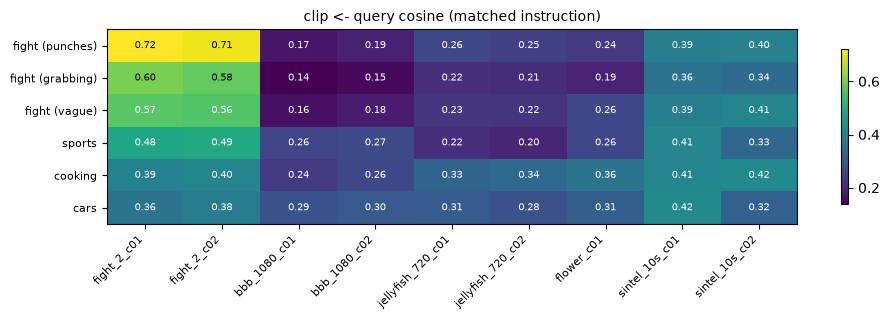

,query,fight_clip,best_benign,margin
0,fight (punches),0.723,0.396,0.326
1,fight (grabbing),0.602,0.359,0.242
2,fight (vague),0.570,0.406,0.164
3,sports,0.492,0.408,0.084
4,cooking,0.404,0.418,-0.014
5,cars,0.383,0.418,-0.035


In [4]:
QUERIES = {
    "fight (punches)":  "Two people fighting each other, throwing punches.",    # grounded visual detail
    "fight (grabbing)": "A physical fight between people, hitting and grabbing.", # paraphrase
    "fight (vague)":    "A violent altercation between two people.",             # abstract wording
    "sports":           "People playing sports on a field.",                      # distractor: shares 'vigorous activity'
    "cooking":         "Someone cooking in a kitchen.",                          # distractor
    "cars":             "Cars driving on a road.",                                # distractor
}
MATCHED = "Given a user query, retrieve the video that best matches the description"

q_emb = embed(embedder, [{"text": q, "instruction": MATCHED} for q in QUERIES.values()])
S = sim_matrix(q_emb, doc_emb)
heatmap(S, CLIP_LABELS, list(QUERIES), "clip <- query cosine (matched instruction)")

def event_margin(scores, pos_idx):
    """Best positive-clip score minus best negative-clip score: the separation margin."""
    s = np.asarray(scores, dtype=float)
    pos, neg = s[list(pos_idx)], np.delete(s, list(pos_idx))
    return dict(pos=float(pos.max()), neg=float(neg.max()),
                margin=float(pos.max() - neg.max()))

rows = []
for i, qname in enumerate(QUERIES):
    m = event_margin(S[i], FIGHT_IDX)
    rows.append(dict(query=qname, fight_clip=round(m["pos"], 3),
                     best_benign=round(m["neg"], 3), margin=round(m["margin"], 3)))
pd.DataFrame(rows)

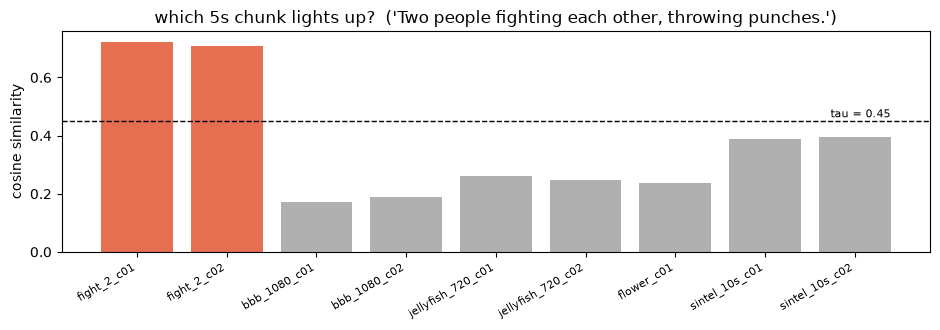

In [5]:
colors = ["#e76f51" if i in FIGHT_IDX else "#b0b0b0" for i in range(len(INDEX))]
plt.figure(figsize=(9.5, 3.4))
plt.bar(range(len(INDEX)), S[0], color=colors)
plt.axhline(0.45, color="k", ls="--", lw=1)
plt.text(len(INDEX) - 0.6, 0.463, "tau = 0.45", fontsize=8, ha="right")
plt.xticks(range(len(INDEX)), CLIP_LABELS, rotation=30, ha="right", fontsize=8)
plt.ylabel("cosine similarity")
plt.title("which 5s chunk lights up?  ('Two people fighting each other, throwing punches.')")
plt.tight_layout(); plt.show()

**What to look for**
- **The event is identified, to the chunk**: the fight query scores ~0.72 on both fight chunks while every benign chunk stays <= 0.41 - the two red bars are the only ones above any sane threshold.
- **Phrasing quality = margin**: grounded visual detail (`throwing punches`, ~+0.33) > paraphrase (~+0.24) > abstract wording (`violent altercation`, ~+0.16). The lab's rule from notebook 02 holds for events too: ground your queries empirically before trusting them.
- **The `sports` trap**: `sports` scores ~0.49 on the fight chunks (and beats its own best benign clip, margin ~+0.08) - 'vigorous physical activity' is shared vocabulary. A naive `sports` detector with a threshold below 0.49 would flag this footage.
- `cooking` / `cars` behave: their best matches are benign chunks and nothing clears 0.45.

## Part 4 - Different query instructions -> what happens to the margin?
Notebook 04 showed instructions *move* embeddings; for detection the question is sharper - does the instruction change the **separation** between event clips and benign clips? Four variants (the wrapper always injects one; `None` means the default `'Represent the user's input.'`):

In [6]:
Q_VARIANTS = {
    "default":               None,      # -> "Represent the user's input."
    "retrieve (matched)":    MATCHED,
    "event (task-matched)":  "Given a description of an event, retrieve the video clips in which the event takes place",
    "classify (mismatched)": "Rate the artistic quality of the video on a scale from one to ten",
}

q_variant_S = {}
rows = []
for vname, instr in Q_VARIANTS.items():
    qe = embed(embedder, [{"text": q, "instruction": instr} for q in QUERIES.values()])
    Sv = sim_matrix(qe, doc_emb)
    q_variant_S[vname] = Sv
    ms = {qn: event_margin(Sv[i], FIGHT_IDX)["margin"] for i, qn in enumerate(QUERIES)}
    rows.append(dict(instruction=vname, **{qn: round(m, 3) for qn, m in ms.items()},
                     mean_fight_margin=round(float(np.mean([m for qn, m in ms.items()
                                                            if qn.startswith("fight")])), 3)))
pd.DataFrame(rows)

,instruction,fight (punches),fight (grabbing),fight (vague),sports,cooking,cars,mean_fight_margin
0,default,0.348,0.248,0.178,0.105,0.004,-0.021,0.258
1,retrieve (matched),0.326,0.242,0.164,0.084,-0.014,-0.035,0.244
2,event (task-matched),0.330,0.236,0.168,0.086,-0.010,-0.023,0.245
3,classify (mismatched),0.197,0.123,0.064,0.031,-0.006,-0.037,0.128


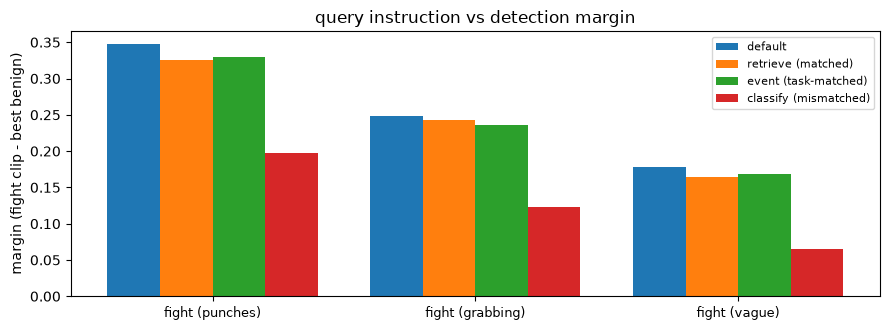

In [7]:
fight_qidx = [i for i, qn in enumerate(QUERIES) if qn.startswith("fight")]
fight_qnames = [list(QUERIES)[i] for i in fight_qidx]
x = np.arange(len(fight_qidx)); w = 0.2
plt.figure(figsize=(9, 3.4))
for vi, vname in enumerate(Q_VARIANTS):
    ms = [event_margin(q_variant_S[vname][i], FIGHT_IDX)["margin"] for i in fight_qidx]
    plt.bar(x + (vi - 1.5) * w, ms, w, label=vname)
plt.axhline(0, color="k", lw=0.6)
plt.xticks(x, fight_qnames, fontsize=9)
plt.ylabel("margin (fight clip - best benign)")
plt.legend(fontsize=8)
plt.title("query instruction vs detection margin")
plt.tight_layout(); plt.show()

**Reading the table/chart**
- **Healthy instructions are interchangeable**: default, canonical `retrieve`, and the task-phrased `event` instruction all cluster within a couple hundredths of each other (margins ~+0.33 / +0.24 / +0.17). Same as notebook 04 found: on the query side the default is not the problem.
- **A mismatched instruction eats the margin**: `classify` cuts the three fight margins to roughly half or less of their healthy values (+0.20 / +0.12 / +0.06) - one wrong sentence in the system prompt. The vague query is hit hardest: its margin ends up one benign lookalike away from a false negative.

## Part 5 - Instructions on the clip (index) side
The deeper asymmetry: query embeddings are made at *query time* - cheap to change. Clip embeddings are made at **index time** - baked into your vector store for millions of chunks. We re-embed the whole index under four clip-side instructions (query stays matched) and watch the fight scores, the margin, and how far the clip embeddings drift:

In [8]:
q_main = embed(embedder, [{"text": QUERIES["fight (punches)"], "instruction": MATCHED}])

C_VARIANTS = {
    "default":                  None,
    "for event retrieval":      "Represent the video clip for retrieval against event descriptions",
    "surveillance style":       "Represent the surveillance footage clip so that events in it can be found by text queries",
    "rate length (mismatched)": "Estimate how many seconds long this video is",
}
rows = []
for cname, cinstr in C_VARIANTS.items():
    ce = embed(embedder, [{"video": c["path"], "instruction": cinstr} for c in INDEX])
    sc = (q_main[0] @ ce.T).float().cpu().numpy()
    m = event_margin(sc, FIGHT_IDX)
    dr = float(np.mean([drift(ce[i], doc_emb[i]) for i in range(len(INDEX))]))
    rows.append(dict(clip_instruction=cname, fight_c01=round(sc[0], 3), fight_c02=round(sc[1], 3),
                     margin=round(m["margin"], 3), clip_drift=round(dr, 3),
                     both_above_045=bool(sc[0] > 0.45 and sc[1] > 0.45)))
pd.DataFrame(rows)

/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


,clip_instruction,fight_c01,fight_c02,margin,clip_drift,both_above_045
0,default,0.727,0.711,0.332,0.000,True
1,for event retrieval,0.688,0.668,0.330,0.066,True
2,surveillance style,0.633,0.645,0.273,0.085,True
3,rate length (mismatched),0.471,0.441,0.115,0.372,False


**Reading the table**
- **Re-tasking the index is mostly harmless**: `for event retrieval` and the surveillance phrasing drift the clips only ~0.07-0.09 and the fight chunks still score 0.63-0.69 - detection survives.
- **A mismatched index instruction poisons detection**: `rate length` collapses the fight chunks to ~0.44-0.47 - at/near the 0.45 threshold (see `both_above_045`) - while drifting every clip by ~0.37. The damage is invisible at query time; you only notice missed alerts. The instruction is part of the **index schema**: to change it, re-embed everything (Qwen's docs say exactly this).

## Part 6 - Margin is the room for your detection threshold
Detection needs a number: alert when `score > tau`. For a single query, the *valid* tau interval is exactly its margin's endpoints - `(best benign, best fight clip)` - anything in between fires on the right clips and nothing else. Run several queries off one shared `tau` and it must fit in the **intersection** of their windows. First the fire table at `tau = 0.45`:

In [9]:
TAU = 0.45
rows = []
for i, qname in enumerate(QUERIES):
    m = event_margin(S[i], FIGHT_IDX)
    fires = [CLIP_LABELS[j] for j in range(len(INDEX)) if S[i, j] > TAU]
    rows.append(dict(query=qname, fight_best=round(m["pos"], 3), benign_best=round(m["neg"], 3),
                     margin=round(m["margin"], 3), fires_at_045=", ".join(fires) or "(none)"))
pd.DataFrame(rows)

,query,fight_best,benign_best,margin,fires_at_045
0,fight (punches),0.723,0.396,0.326,"fight_2_c01, fight_2_c02"
1,fight (grabbing),0.602,0.359,0.242,"fight_2_c01, fight_2_c02"
2,fight (vague),0.570,0.406,0.164,"fight_2_c01, fight_2_c02"
3,sports,0.492,0.408,0.084,"fight_2_c01, fight_2_c02"
4,cooking,0.404,0.418,-0.014,(none)
5,cars,0.383,0.418,-0.035,(none)


valid shared-tau window over the 3 fight queries (intersection of per-query windows):
  default                (0.447, 0.598)   width = 0.150
  retrieve (matched)     (0.406, 0.570)   width = 0.164
  event (task-matched)   (0.383, 0.551)   width = 0.168
  classify (mismatched)  (0.428, 0.492)   width = 0.064


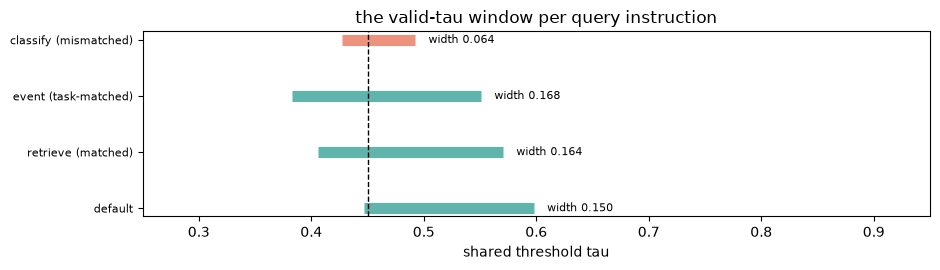

In [10]:
print("valid shared-tau window over the 3 fight queries (intersection of per-query windows):")
for vname, Sv in q_variant_S.items():
    lo = max(event_margin(Sv[i], FIGHT_IDX)["neg"] for i in fight_qidx)
    hi = min(event_margin(Sv[i], FIGHT_IDX)["pos"] for i in fight_qidx)
    print(f"  {vname:22s} ({lo:.3f}, {hi:.3f})   width = {hi - lo:.3f}")

fig, ax = plt.subplots(figsize=(9.5, 2.8))
for r, (vname, Sv) in enumerate(q_variant_S.items()):
    lo = max(event_margin(Sv[i], FIGHT_IDX)["neg"] for i in fight_qidx)
    hi = min(event_margin(Sv[i], FIGHT_IDX)["pos"] for i in fight_qidx)
    ax.plot([lo, hi], [r, r], lw=8, solid_capstyle="butt", alpha=0.75,
            color="#e76f51" if vname == "classify (mismatched)" else "#2a9d8f")
    ax.text(hi + 0.012, r, f"width {hi - lo:.3f}", va="center", fontsize=8)
ax.axvline(TAU, color="k", ls="--", lw=1)
ax.set_yticks(range(len(q_variant_S))); ax.set_yticklabels(list(q_variant_S), fontsize=8)
ax.set_xlim(0.25, 0.95); ax.set_xlabel("shared threshold tau")
ax.set_title("the valid-tau window per query instruction")
plt.tight_layout(); plt.show()

**Reading the table/chart**
- At `tau = 0.45` all three fight phrasings fire **exactly** on the two fight chunks - but `sports` fires on them too (false alarm), and `cooking`/`cars` on nothing. **Absolute thresholds are per-query calibrated** - `sports`' window is only ~0.08 wide.
- A shared `tau` must live in the intersection: healthy instructions leave a **~0.15-wide** window; the mismatched `classify` instruction shrinks it to **~0.06** - the vague query's positives sink to ~0.49 while benign noise stays ~0.43. One more sloppy phrasing and the window *closes* (empty intersection -> no single tau works at all).
- Two robust alternatives when margins are thin: **rank-based firing** (alert on argmax / top-k, which only needs margin > 0 per query) or the nb-05 recipe - cheap embedding recall + **reranker** precision on the shortlist.

## Findings & guidance
1. **The pipeline works end to end**: chunk -> embed once -> query identified the fight in both 5-second windows (fight ~0.72 vs benign <= 0.41) with zero training. Chunk duration is your time resolution - and the 2.52 s tail chunk embeds fine (the 4-frame floor).
2. **Margin is the detection currency**: grounded phrasing (~+0.33) beats paraphrase (~+0.24) beats vague (~+0.16) - and margin is literally the interval of valid thresholds. Thin margins mean fragile detectors.
3. **Instructions, both sides**: a mismatched *query* instruction cuts margins roughly in half (+0.35 -> +0.20 on the grounded query; shared-tau window 0.15 -> 0.06). A mismatched *clip* instruction is worse - it **poisons the index at index time** (fight 0.72 -> 0.44, drift ~0.37, missed alert at tau = 0.45) and cannot be repaired at query time.
4. **Watch the cross-event traps**: `sports` scored ~0.49 on fight footage. Calibrate per query, fire rank-based, or rerank the shortlist (notebook 05).

**Exercise**: `~/study/data/fight_1.mp4` is 17.96 s of 2160x4096 portrait footage - point `SRC` at it and re-run (4 chunks; the 4K portrait source gets downscaled into the same per-frame budget anyway, nb 03's rule). Then try a chunk-length sweep (5 s -> 10 s -> 15 s): longer chunks blur *when* the event happened, shorter chunks cost more index embeddings - the budget-vs-granularity tension of notebook 03, but in time.